# Temporal Fusion: Kernel Aggregation for Sparse News Data

Aligning irregular news events with dense market time series using exponential decay kernels.


In [2]:
import os

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from momentfm import MOMENTPipeline
import torch
from openai import OpenAI
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [3]:
ts_path = Path.cwd() / "data" / "time_series"

text_path = Path.cwd() / "data" / "text"

images_path = Path.cwd() / "images"
images_path.mkdir(parents=True, exist_ok=True)

csv_files = sorted(ts_path.glob("*.csv"))

In [4]:
print(f"{len(csv_files)} Ticker(s) found in {ts_path}")

ticker_to_df = {}
n_tickers = 100

for i, csv_file in enumerate(csv_files):

    if i >= n_tickers:
        break

    df = pd.read_csv(csv_file)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)
    df = df.dropna(subset=["Date"]).sort_values("Date")
    df["Date"] = df["Date"].dt.tz_convert("UTC").dt.tz_localize(None)
    ticker_to_df[csv_file.stem] = df

4213 Ticker(s) found in /home/rodrigodog/latent_fusion/data/time_series


## News Sparsity Challenge

Financial news data exhibits **critical sparsity patterns** that complicate direct alignment with time series:

### The Sparsity Problem

1. **Temporal Irregularity**: News arrives in bursts and gaps
   - Some stocks get 10+ articles per day
   - Others have days, weeks, or months with zero coverage
   - Creates jagged, non-uniform temporal distribution

2. **Mismatch with Market Data**: 
   - Market data: daily OHLCV (continuous, dense)
   - News data: event-driven (sparse, irregular)
   - Direct alignment impossible on non-news days

3. **Information Loss**:
   - Naive approach: only embeddings on news days
   - Result: **~70-90% of trading days have no context**
   - Market continues moving while data gaps exist


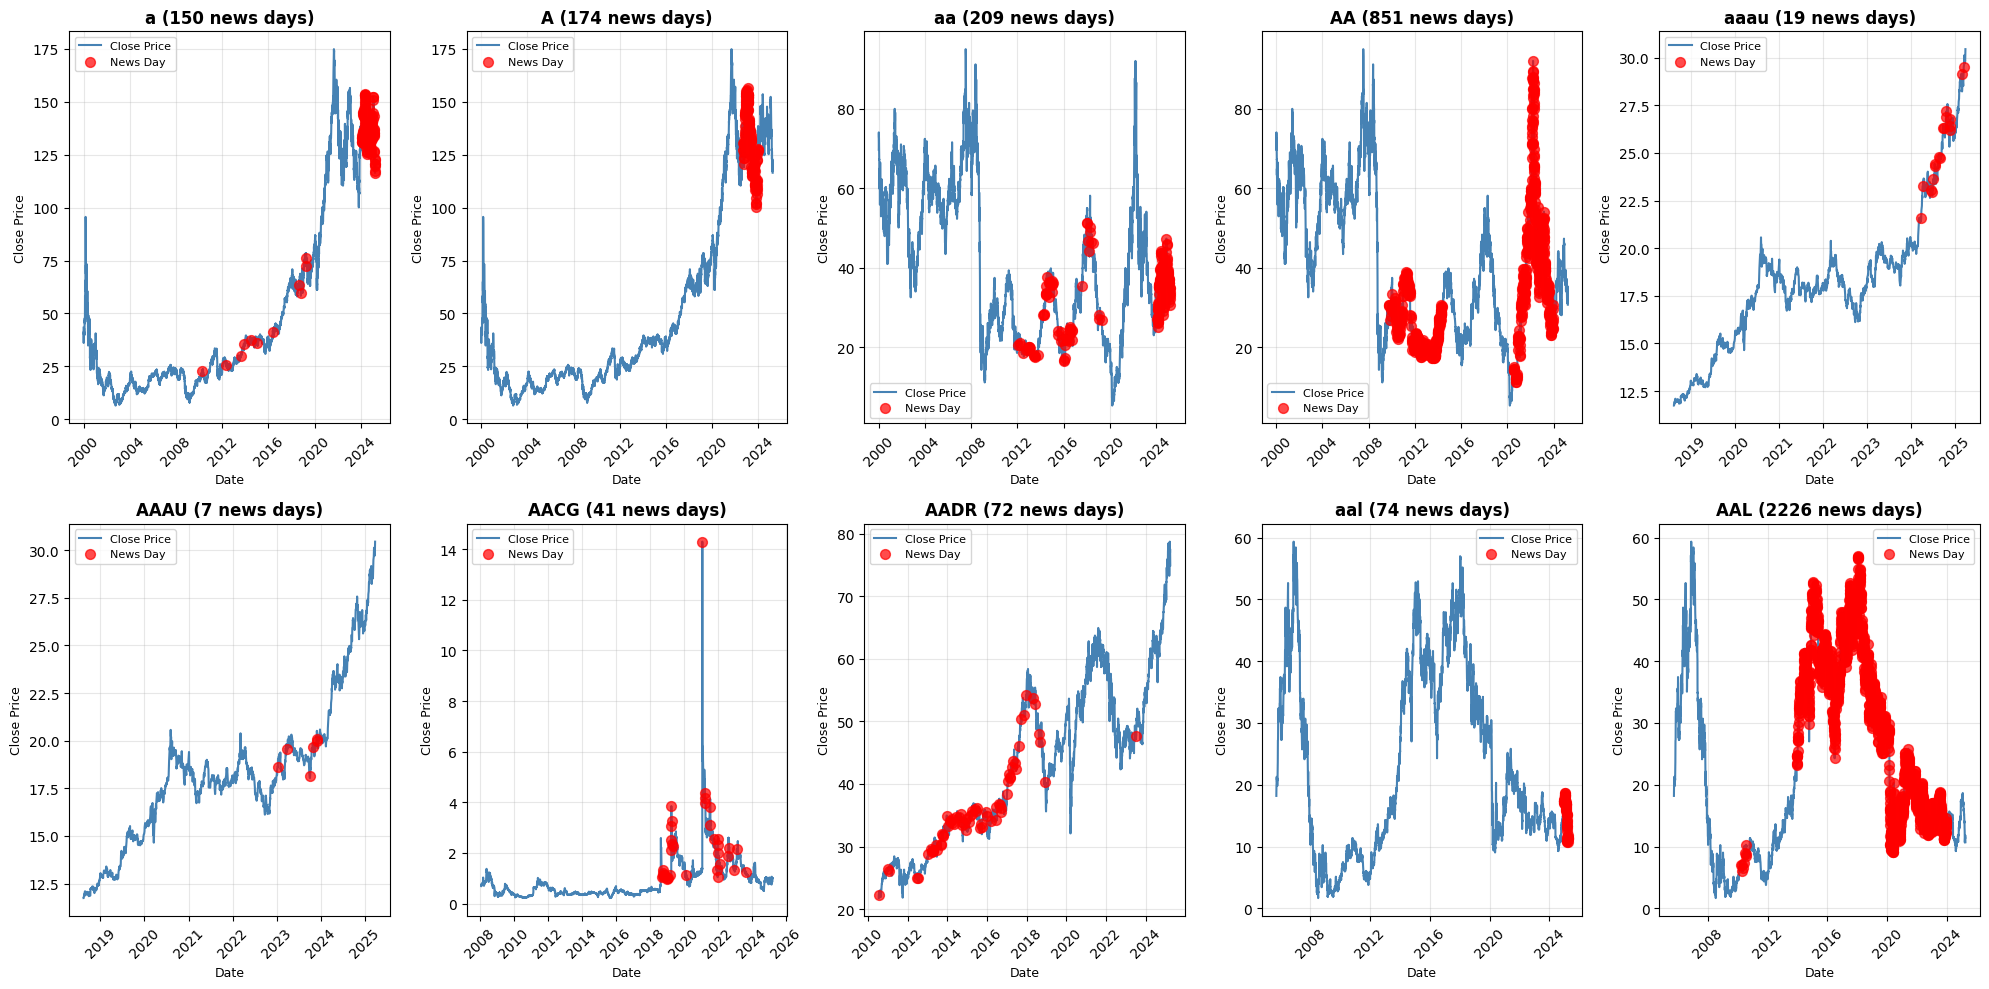

In [5]:
aligned_df = pd.read_csv('data/aligned_news_timeseries.csv')
aligned_df['news_date'] = pd.to_datetime(aligned_df['news_date'])
all_tickers = aligned_df['stock_symbol'].unique()
first_10_tickers = all_tickers[:10]

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, ticker in enumerate(first_10_tickers):
    ax = axes[idx]
    
    # Get ticker data
    ticker_df = aligned_df[aligned_df['stock_symbol'] == ticker].copy()
    
    # Load time series data
    ts_file = Path('data/time_series') / f'{ticker.lower()}.csv'
    if ts_file.exists():
        ts_df = pd.read_csv(ts_file)
        ts_df['Date'] = pd.to_datetime(ts_df['Date'], utc=True).dt.tz_localize(None)
        ts_df = ts_df.sort_values('Date')
        
        news_dates = pd.to_datetime(ticker_df['news_date'], utc=True).dt.tz_localize(None).dt.date.unique()
        news_dates_set = set(news_dates)
        
        ax.plot(ts_df['Date'], ts_df['Close'], linewidth=1.5, color='steelblue', label='Close Price')
        
        # Mark dates with news as red dots
        ts_with_news = ts_df[ts_df['Date'].dt.date.isin(news_dates_set)]
        ax.scatter(ts_with_news['Date'], ts_with_news['Close'], color='red', s=50, zorder=5, label='News Day', alpha=0.7)
        
        # Formatting
        ax.set_title(f'{ticker} ({len(news_dates)} news days)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Close Price', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, f'{ticker} data not found', ha='center', va='center')
        ax.set_title(f'{ticker}')

plt.tight_layout()
plt.show()

In [8]:
import json
import torch
from sentence_transformers import SentenceTransformer

ticker = list(ticker_to_df.keys())[0]
jsonl_path = text_path / f"{ticker.upper()}.jsonl"

articles = []
with open(jsonl_path) as f:
    for line in f:
        articles.append(json.loads(line))

print(f"Loaded {len(articles)} articles from {ticker}.jsonl")
print(f"Date range: {articles[0]['Date']} to {articles[-1]['Date']}")
print(f"Sample article length: {len(articles[0]['Article'])} chars")

text_alignment_df = pd.DataFrame([
    {
        "ticker": a["Stock_symbol"].upper(),
        "date": pd.to_datetime(a["Date"]),
        "text": a["Article"],
        "url": a["Url"]
    }
    for a in articles
])

text_alignment_df = text_alignment_df.dropna(subset=["text"])
print(f"\nText alignment DF shape: {text_alignment_df.shape}")

Loaded 642 articles from a.jsonl
Date range: 2025-04-15 to 2010-04-15
Sample article length: 1062 chars

Text alignment DF shape: (642, 4)


In [8]:
cluster_df = text_alignment_df[["ticker", "date", "text"]].copy()
cluster_df["ticker"] = cluster_df["ticker"].astype(str)
cluster_df["text"] = cluster_df["text"].fillna("").astype(str)
cluster_df = cluster_df[cluster_df["text"].str.strip().str.len() > 0].reset_index(drop=True)

print(f"Embedding {len(cluster_df)} articles...")

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embedding_dim = embedding_model.get_sentence_embedding_dimension()
print(f"Embedding dimension: {embedding_dim}")

batch_size = 32
x_text_list = []

for i in range(0, len(cluster_df), batch_size):
    batch_texts = cluster_df["text"].iloc[i:i+batch_size].tolist()
    batch_texts = [t[:4000] for t in batch_texts]  # truncate long texts
    embeddings = embedding_model.encode(batch_texts, show_progress_bar=False)
    x_text_list.append(embeddings)
    if (i + batch_size) % 128 == 0:
        print(f"  [{i}/{len(cluster_df)}]")

x_text = np.vstack(x_text_list)
cluster_df["text_embedding"] = list(x_text)
print(f"✓ Embeddings shape: {x_text.shape}")

Embedding 642 articles...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384
  [96/642]
  [224/642]
  [352/642]
  [480/642]
  [608/642]
✓ Embeddings shape: (642, 384)


In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from openai import OpenAI
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set")

client = OpenAI(api_key=api_key)

if "text_alignment_df" not in globals() or text_alignment_df is None:
    if "cluster_df" in globals() and isinstance(cluster_df, pd.DataFrame):
        req = {"ticker", "date", "text"}
        if req.issubset(set(cluster_df.columns)):
            text_alignment_df = cluster_df[["ticker", "date", "text"]].copy()
        else:
            raise ValueError("cluster_df exists but does not contain ticker/date/text columns")
    elif "articles" in globals() and isinstance(articles, list) and len(articles) > 0:
        text_alignment_df = pd.DataFrame([
            {
                "ticker": a.get("Stock_symbol", "").upper(),
                "date": pd.to_datetime(a.get("Date"), errors="coerce"),
                "text": a.get("Article", "")
            }
            for a in articles
        ]).dropna(subset=["date"])
    else:
        raise NameError("text_alignment_df is missing. Run Cell 7 first, or define cluster_df with ticker/date/text.")

llm_cluster_df = text_alignment_df[["ticker", "date", "text"]].copy()
llm_cluster_df["ticker"] = llm_cluster_df["ticker"].astype(str).str.upper()
llm_cluster_df["text"] = llm_cluster_df["text"].fillna("").astype(str)
llm_cluster_df = llm_cluster_df[llm_cluster_df["text"].str.strip().str.len() > 0].reset_index(drop=True)

analysis_model = "gpt-4o-mini"
embedding_model = "text-embedding-3-small"
embedding_dim = 512

cache_dir = Path("cache") / "text"
cache_dir.mkdir(parents=True, exist_ok=True)
cache_text_file = cache_dir / "gpt_conditioned_text.parquet"
cache_emb_file = cache_dir / "gpt_conditioned_embeddings.npy"

def build_firm_prompt(ticker, date_str, raw_text):
    return f"""You are a professional equity research analyzer for an institutional investment firm.
Write a firm-specific analyst memo for {ticker.upper()} based on the news below.
Date: {date_str}
News:
{raw_text if raw_text.strip() else 'No concrete article text was provided for this date.'}

Return exactly 10 concise bullet points focused on {ticker.upper()}:
- what this means for this specific firm
- business segment impact
- near-term catalysts
- medium-term risks
- earnings and margin implications
- balance sheet or liquidity implications
- competitive positioning
- regulatory or macro sensitivity
- sentiment direction with confidence
- 1-3 month investment takeaway
"""

llm_cluster_df["prompt_text"] = llm_cluster_df.apply(
    lambda r: build_firm_prompt(
        ticker=r["ticker"],
        date_str=pd.to_datetime(r["date"]).strftime("%Y-%m-%d"),
        raw_text=r["text"][:12000],
    ),
    axis=1,
)
llm_cluster_df["cache_key"] = (
    llm_cluster_df["ticker"].astype(str) + "|" +
    pd.to_datetime(llm_cluster_df["date"]).dt.strftime("%Y-%m-%d") + "|" +
    llm_cluster_df["text"].astype(str).str.slice(0, 1000)
).map(lambda s: str(abs(hash(s))))

cached_text_df = None
if cache_text_file.exists():
    try:
        cached_text_df = pd.read_parquet(cache_text_file)
        needed_cols = {"cache_key", "gpt_text"}
        if not needed_cols.issubset(set(cached_text_df.columns)):
            cached_text_df = None
    except Exception:
        cached_text_df = None

def summarize_with_gpt(prompt_text):
    response = client.responses.create(
        model=analysis_model,
        input=prompt_text,
        max_output_tokens=500,
    )
    return response.output_text.strip()

if cached_text_df is not None:
    key_to_text = dict(zip(cached_text_df["cache_key"].astype(str), cached_text_df["gpt_text"].astype(str)))
else:
    key_to_text = {}

def flush_text_cache(existing_df, pending_rows):
    if existing_df is None:
        base_df = llm_cluster_df[["cache_key", "ticker", "date", "text", "prompt_text", "gpt_text"]].copy()
    else:
        if pending_rows:
            base_df = pd.concat([
                existing_df,
                pd.DataFrame(pending_rows)
            ], ignore_index=True).drop_duplicates(subset=["cache_key"], keep="last")
        else:
            base_df = existing_df
    base_df.to_parquet(cache_text_file, index=False)
    return base_df

print(f"Generating GPT-conditioned text for {len(llm_cluster_df)} samples...")
gpt_texts = []
new_rows = []
checkpoint_every = 20

try:
    for i, row in llm_cluster_df.iterrows():
        key = str(row["cache_key"])
        if key in key_to_text and key_to_text[key].strip():
            transformed = key_to_text[key]
        else:
            transformed = summarize_with_gpt(row["prompt_text"])
            if not transformed:
                transformed = row["prompt_text"]
            key_to_text[key] = transformed
            new_rows.append({"cache_key": key, "gpt_text": transformed})
        gpt_texts.append(transformed)
        if (i + 1) % checkpoint_every == 0 and len(new_rows) > 0:
            temp_df = llm_cluster_df.iloc[: i + 1].copy()
            temp_df["gpt_text"] = gpt_texts
            existing = cached_text_df if cached_text_df is not None else temp_df[["cache_key", "ticker", "date", "text", "prompt_text", "gpt_text"]].copy()
            cached_text_df = flush_text_cache(existing, new_rows)
            new_rows = []
        if (i + 1) % 64 == 0 or (i + 1) == len(llm_cluster_df):
            print(f"  GPT pass [{i + 1}/{len(llm_cluster_df)}]")
except KeyboardInterrupt:
    print("\nInterrupted. Saving partial GPT cache...")
    raise
finally:
    if len(gpt_texts) > 0:
        llm_cluster_df.loc[: len(gpt_texts) - 1, "gpt_text"] = gpt_texts
    if len(new_rows) > 0 or cached_text_df is None:
        if "gpt_text" in llm_cluster_df.columns:
            cached_text_df = flush_text_cache(cached_text_df, new_rows)
        new_rows = []

if "gpt_text" not in llm_cluster_df.columns:
    llm_cluster_df["gpt_text"] = llm_cluster_df["cache_key"].map(key_to_text).fillna(llm_cluster_df["prompt_text"])
else:
    llm_cluster_df["gpt_text"] = llm_cluster_df["gpt_text"].fillna(llm_cluster_df["cache_key"].map(key_to_text)).fillna(llm_cluster_df["prompt_text"])

print(f"Embedding {len(llm_cluster_df)} GPT-conditioned samples...")
batch_size = 32
prompt_embeddings = []

for i in range(0, len(llm_cluster_df), batch_size):
    batch_inputs = llm_cluster_df["gpt_text"].iloc[i:i + batch_size].tolist()
    response = client.embeddings.create(
        model=embedding_model,
        input=batch_inputs,
        dimensions=embedding_dim,
    )
    batch_vectors = [np.array(item.embedding, dtype=np.float32) for item in response.data]
    prompt_embeddings.extend(batch_vectors)
    if len(prompt_embeddings) > 0:
        np.save(cache_emb_file, np.vstack(prompt_embeddings))
    if (i + batch_size) % 128 == 0 or (i + batch_size) >= len(llm_cluster_df):
        print(f"  Embed pass [{min(i + batch_size, len(llm_cluster_df))}/{len(llm_cluster_df)}]")

x_text = np.vstack(prompt_embeddings)
np.save(cache_emb_file, x_text)

cluster_df = llm_cluster_df[["ticker", "date", "text", "prompt_text", "gpt_text"]].copy()
cluster_df["text_embedding"] = list(x_text)
print(f"✓ GPT-conditioned embeddings shape: {x_text.shape}")
print(f"✓ Cached text: {cache_text_file}")
print(f"✓ Cached embeddings: {cache_emb_file}")

Generating GPT-conditioned text for 642 samples...


## Kernel Aggregation: Handling News Sparsity

### The Problem: Event Sparsity

Financial news is **sparse and irregular**:
- Some days have 10+ articles, others have none
- Direct embedding matching breaks on non-news days
- Time series has DAILY samples, news has EVENT samples
- Can't simply align: (6172 events) ≠ (4495 days)

### The Solution: Kernel Aggregation

**Formula**: Project sparse events onto dense time axis using exponential decay kernel

$$z_{\text{text}}(t) = \sum_{i=1}^{E} \exp(-\lambda \cdot (t - t_i)) \cdot z_{\text{event}_i} \cdot \mathbb{1}_{t \geq t_i}$$

Where:
- $z_{\text{event}_i}$ = embedding of $i$-th news article
- $t_i$ = time of $i$-th article
- $\lambda$ = decay rate (controls "memory half-life")
- $\mathbb{1}_{t \geq t_i}$ = mask future events (no lookahead)

### Why This Works

1. **Closure**: Maps E events → T time steps (all days have context)
2. **Causality**: Only uses past news (exponential mask)
3. **Smoothness**: Recent news weighted more heavily
4. **Interpretability**: λ controls temporal weight distribution

### Decay Interpretation

| λ | Meaning | Half-life |
|---|---------|-----------|
| **0.01** | Long memory | 69 days (quarterly themes) |
| **0.05** | Medium memory | 14 days (monthly signals) |
| **0.1** | Short memory | 7 days (weekly noise) |

In [11]:
def build_text_context(z_events, event_times, time_steps, lambda_=0.1):
    """
    Kernel aggregation: projects events onto time axis
    
    Args:
        z_events: [E, D] event embeddings
        event_times: [E] event timestamps (as float timestamps)
        time_steps: [T] target time steps
        lambda_: decay parameter
    
    Returns:
        z_text_context: [T, D] aggregated text context at each time step
    """
    z_events = torch.FloatTensor(z_events)
    event_times = torch.FloatTensor(event_times)
    time_steps = torch.FloatTensor(time_steps)
    
    delta_t = time_steps.unsqueeze(1) - event_times.unsqueeze(0)  # [T, E]
    
    mask = delta_t < 0  # mask future events
    delta_t = torch.clamp(delta_t, min=0)
    
    weights = torch.exp(-lambda_ * delta_t)  # exponential decay
    weights[mask] = 0
    
    weights = weights / (weights.sum(dim=1, keepdim=True) + 1e-8)  # normalize
    
    z_text_context = weights @ z_events  # [T, D]
    
    return z_text_context.numpy()

# Prepare data for kernel aggregation
cluster_df["date_float"] = cluster_df["date"].astype(np.int64) / 1e9
z_events = x_text  # [E, D]
event_times = cluster_df["date_float"].values  # [E]

# Create time_steps: every trading day in the date range
date_min = cluster_df["date"].min()
date_max = cluster_df["date"].max()
time_steps_range = pd.date_range(date_min, date_max, freq='D')
time_steps = (time_steps_range.astype(np.int64) / 1e9).values

print(f"Events: {len(event_times)}, Date range: {date_min.date()} to {date_max.date()}")
print(f"Time steps: {len(time_steps)} days")

# Apply kernel aggregation with multiple lambda values
lambdas = [0.01, 0.05, 0.1]
z_context_dict = {}

for lam in lambdas:
    z_context = build_text_context(z_events, event_times, time_steps, lambda_=lam)
    z_context_dict[lam] = z_context
    print(f"✓ Lambda={lam}: context shape {z_context.shape}")

Events: 642, Date range: 2010-04-15 to 2025-04-15
Time steps: 5480 days
✓ Lambda=0.01: context shape (5480, 384)
✓ Lambda=0.05: context shape (5480, 384)
✓ Lambda=0.1: context shape (5480, 384)


## Realized Volatility Analysis

Realized volatility measures the actual price fluctuations observed in the market over a specific period.

### Calculation Methods

1. **Parkinson Volatility** (High-Low range):
$$\sigma_{\text{Parkinson}} = \sqrt{\frac{1}{N} \sum \left(\ln\frac{H_i}{L_i}\right)^2 / (4\ln 2)} \times \sqrt{252}$$

2. **Close-to-Close Volatility** (Historical):
$$\sigma_{\text{Historical}} = \sqrt{\text{Var}(\text{returns})} \times \sqrt{252}$$

3. **Garman-Klass Volatility** (combines OHLC):
$$\sigma_{\text{GK}} = \sqrt{\frac{1}{N}\sum \left[0.5(\ln H_i/L_i)^2 - (2\ln 2 - 1)(\ln C_i/O_i)^2\right]} \times \sqrt{252}$$


This cell aligns kernel days with market data, computes three realized volatilities (Historical, Parkinson, and Garman-Klass), and creates `combined_vol` as their average.

It then attaches `combined_vol` to the daily aligned dataframe so the next PCA plot can color kernel days by this combined volatility signal.

Time series: 6348 records, 2000-01-03 05:00:00 to 2025-03-28 04:00:00
Volatility range: 0.0822 to 2.0341
✓ Merged DF: 3763 rows with valid volatility
Date range: 2010-04-15 00:00:00 to 2025-03-28 00:00:00
Volatility stats:
count    3763.000000
mean        0.263238
std         0.116479
min         0.082242
25%         0.189664
50%         0.241029
75%         0.303240
max         0.950589
Name: vol_20d, dtype: float64
Clean data points: 6328

Volatility Summary (annualized):
  Historical Vol: 0.3397 ± 0.2234
  Parkinson Vol:  0.2863 ± 0.1680
  Garman-Klass:   0.2847 ± 0.1619
  Combined Vol:   0.3036 ± 0.1813


/tmp/ipykernel_55599/1313680700.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vol_ts_clean['combined_vol'] = vol_ts_clean[['historical_vol', 'parkinson_vol', 'garman_klass_vol']].mean(axis=1)



✓ Saved to images/realized_volatility_analysis.png


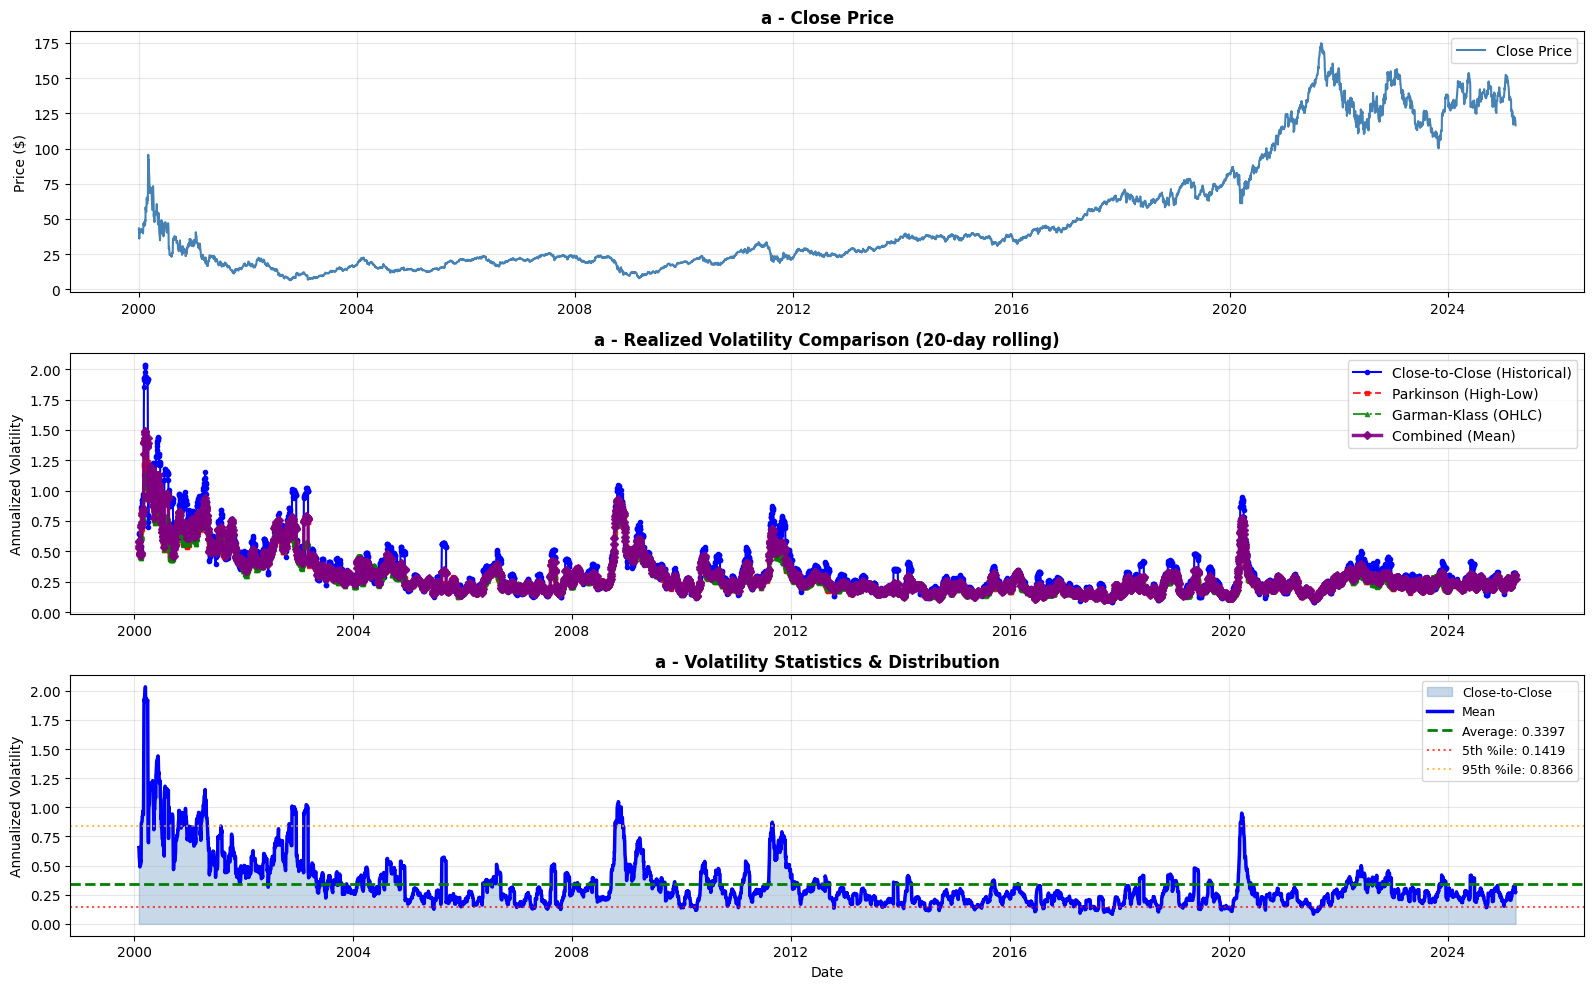

In [21]:
# Prepare kernel aggregation context and calculate realized volatility metrics
ticker_for_vol = list(ticker_to_df.keys())[0]
ts = ticker_to_df[ticker_for_vol].copy().sort_values('Date')

ts['returns'] = ts['Close'].pct_change()
ts['vol_20d'] = ts['returns'].rolling(20).std() * np.sqrt(252)  # annualized

print(f"Time series: {len(ts)} records, {ts['Date'].min()} to {ts['Date'].max()}")
print(f"Volatility range: {ts['vol_20d'].min():.4f} to {ts['vol_20d'].max():.4f}")

# Normalize dates (remove time component)
ts['Date_norm'] = ts['Date'].dt.normalize()

# Create alignment dataframe with scalar features only
alignment_df = pd.DataFrame({'date': time_steps_range})
alignment_df['date_norm'] = pd.to_datetime(alignment_df['date']).dt.normalize()

# Add z_context as lists of embeddings
alignment_df['z_context_01'] = [z_context_dict[0.01][i] for i in range(len(time_steps_range))]
alignment_df['z_context_05'] = [z_context_dict[0.05][i] for i in range(len(time_steps_range))]
alignment_df['z_context_10'] = [z_context_dict[0.1][i] for i in range(len(time_steps_range))]

# Merge on normalized date
merged_df = alignment_df.merge(
    ts[['Date_norm', 'Close', 'vol_20d']],
    left_on='date_norm',
    right_on='Date_norm',
    how='inner'
)

# Keep rows with valid volatility
merged_df = merged_df.dropna(subset=['vol_20d']).copy()

print(f"✓ Merged DF: {len(merged_df)} rows with valid volatility")
if len(merged_df) > 0:
    print(f"Date range: {merged_df['date'].min()} to {merged_df['date'].max()}")
    print(f"Volatility stats:\n{merged_df['vol_20d'].describe()}")

# Calculate realized volatility metrics
vol_ts = ts.copy()
rolling_window = 20

vol_ts['historical_vol'] = vol_ts['returns'].rolling(rolling_window).std() * np.sqrt(252)

if 'High' in vol_ts.columns and 'Low' in vol_ts.columns:
    vol_ts['hl_ratio'] = np.log(vol_ts['High'] / vol_ts['Low'])
    vol_ts['parkinson_vol'] = (vol_ts['hl_ratio'].rolling(rolling_window).apply(
        lambda x: np.sqrt(np.sum(x**2) / len(x) / (4 * np.log(2)))
    )) * np.sqrt(252)
    
    if 'Open' in vol_ts.columns:
        vol_ts['oc_ratio'] = np.log(vol_ts['Close'] / vol_ts['Open'])
        
        gk_values = []
        for i in range(len(vol_ts)):
            if i < rolling_window - 1:
                gk_values.append(np.nan)
            else:
                window_data = vol_ts.iloc[i-rolling_window+1:i+1]
                hl_log = np.log(window_data['High'] / window_data['Low'])
                co_log = np.log(window_data['Close'] / window_data['Open'])
                gk = np.sqrt(
                    0.5 * np.sum(hl_log**2) / rolling_window - 
                    (2 * np.log(2) - 1) * np.sum(co_log**2) / rolling_window
                ) * np.sqrt(252)
                gk_values.append(gk)
        vol_ts['garman_klass_vol'] = gk_values

vol_ts_clean = vol_ts.dropna(subset=['historical_vol'])
print(f"Clean data points: {len(vol_ts_clean)}")
print(f"\nVolatility Summary (annualized):")
print(f"  Historical Vol: {vol_ts_clean['historical_vol'].mean():.4f} ± {vol_ts_clean['historical_vol'].std():.4f}")
if 'parkinson_vol' in vol_ts_clean.columns:
    print(f"  Parkinson Vol:  {vol_ts_clean['parkinson_vol'].mean():.4f} ± {vol_ts_clean['parkinson_vol'].std():.4f}")
if 'garman_klass_vol' in vol_ts_clean.columns:
    print(f"  Garman-Klass:   {vol_ts_clean['garman_klass_vol'].mean():.4f} ± {vol_ts_clean['garman_klass_vol'].std():.4f}")

# Combined volatility: mean of all three methods
vol_ts_clean['combined_vol'] = vol_ts_clean[['historical_vol', 'parkinson_vol', 'garman_klass_vol']].mean(axis=1)
vol_ts_clean = vol_ts_clean.dropna(subset=['combined_vol'])
print(f"  Combined Vol:   {vol_ts_clean['combined_vol'].mean():.4f} ± {vol_ts_clean['combined_vol'].std():.4f}")

# Add combined volatility to merged_df
vol_for_merge = vol_ts_clean[['Date_norm', 'combined_vol']].drop_duplicates(subset=['Date_norm']).rename(columns={'combined_vol': 'combined_vol'})
merged_df = merged_df.merge(vol_for_merge, left_on='date_norm', right_on='Date_norm', how='left')

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

ax = axes[0]
ax.plot(vol_ts['Date'], vol_ts['Close'], 'steelblue', linewidth=1.5, label='Close Price')
ax.set_title(f'{ticker_for_vol} - Close Price', fontweight='bold', fontsize=12)
ax.set_ylabel('Price ($)')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(vol_ts_clean['Date'], vol_ts_clean['historical_vol'], 'b-', linewidth=1.5, label='Close-to-Close (Historical)', marker='o', markersize=3)
if 'parkinson_vol' in vol_ts_clean.columns:
    ax.plot(vol_ts_clean['Date'], vol_ts_clean['parkinson_vol'], 'r--', linewidth=1.5, label='Parkinson (High-Low)', alpha=0.8, marker='s', markersize=3)
if 'garman_klass_vol' in vol_ts_clean.columns:
    ax.plot(vol_ts_clean['Date'], vol_ts_clean['garman_klass_vol'], 'g-.', linewidth=1.5, label='Garman-Klass (OHLC)', alpha=0.8, marker='^', markersize=3)
if 'combined_vol' in vol_ts_clean.columns:
    ax.plot(vol_ts_clean['Date'], vol_ts_clean['combined_vol'], 'purple', linewidth=2.5, label='Combined (Mean)', marker='D', markersize=4, alpha=0.9)
ax.set_title(f'{ticker_for_vol} - Realized Volatility Comparison (20-day rolling)', fontweight='bold', fontsize=12)
ax.set_ylabel('Annualized Volatility')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax = axes[2]
vol_range = vol_ts_clean['historical_vol'].quantile([0.05, 0.95])
ax.fill_between(vol_ts_clean['Date'], vol_ts_clean['historical_vol'], alpha=0.3, color='steelblue', label='Close-to-Close')
ax.plot(vol_ts_clean['Date'], vol_ts_clean['historical_vol'], 'b-', linewidth=2.5, label='Mean')
ax.axhline(vol_ts_clean['historical_vol'].mean(), color='green', linestyle='--', linewidth=2, label=f"Average: {vol_ts_clean['historical_vol'].mean():.4f}")
ax.axhline(vol_range.iloc[0], color='red', linestyle=':', linewidth=1.5, alpha=0.7, label=f"5th %ile: {vol_range.iloc[0]:.4f}")
ax.axhline(vol_range.iloc[1], color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=f"95th %ile: {vol_range.iloc[1]:.4f}")
ax.set_title(f'{ticker_for_vol} - Volatility Statistics & Distribution', fontweight='bold', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('images/realized_volatility_analysis.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved to images/realized_volatility_analysis.png")
plt.show()


## Kernel Days PCA Colored by Combined Volatility

This plot projects the **kernel-aggregated context** into 2D (PCA) for each decay value $\lambda \in \{0.01, 0.05, 0.1\}$.

### PCA (what it means here)

- PCA is a linear dimensionality-reduction method that transforms high-dimensional kernel embeddings into orthogonal components.
- **PC1** is the direction of maximum variance in the kernel context; **PC2** is the second-most, orthogonal to PC1.
- Points that are close in the PCA plane have similar kernel-context representations.
- The percentages in the title (PCA1, PCA2) show how much total variance each axis explains.

### What is plotted

- **All kernel days are included** (full `time_steps_range`), not only market-overlap days.
- Each point is one day of kernel context after aggregation.
- PCA is fit on kernel context for each $\lambda$ and then plotted on PC1 vs PC2.

### Volatility color mapping

Color is based on **combined volatility**:

$$
\text{combined\_vol}_t = \frac{\sigma_{\text{historical},t} + \sigma_{\text{parkinson},t} + \sigma_{\text{gk},t}}{3}
$$

- Colored points: kernel days where `combined_vol` is available.
- Gray points: kernel days without `combined_vol` (typically due to rolling-window warmup or missing OHLC inputs).
- Color values are clipped to the 5th-95th percentile range for readability.

### Why this view is useful

- Keeps the full temporal kernel representation visible.
- Highlights where market volatility information exists.
- Lets you compare how different decay memories ($\lambda$) reshape the kernel-context geometry.

✓ Saved to images/kernel_days_combined_vol_colormap.png
  Kernel context days shown (all): 5480
  Kernel days with combined volatility: 3763


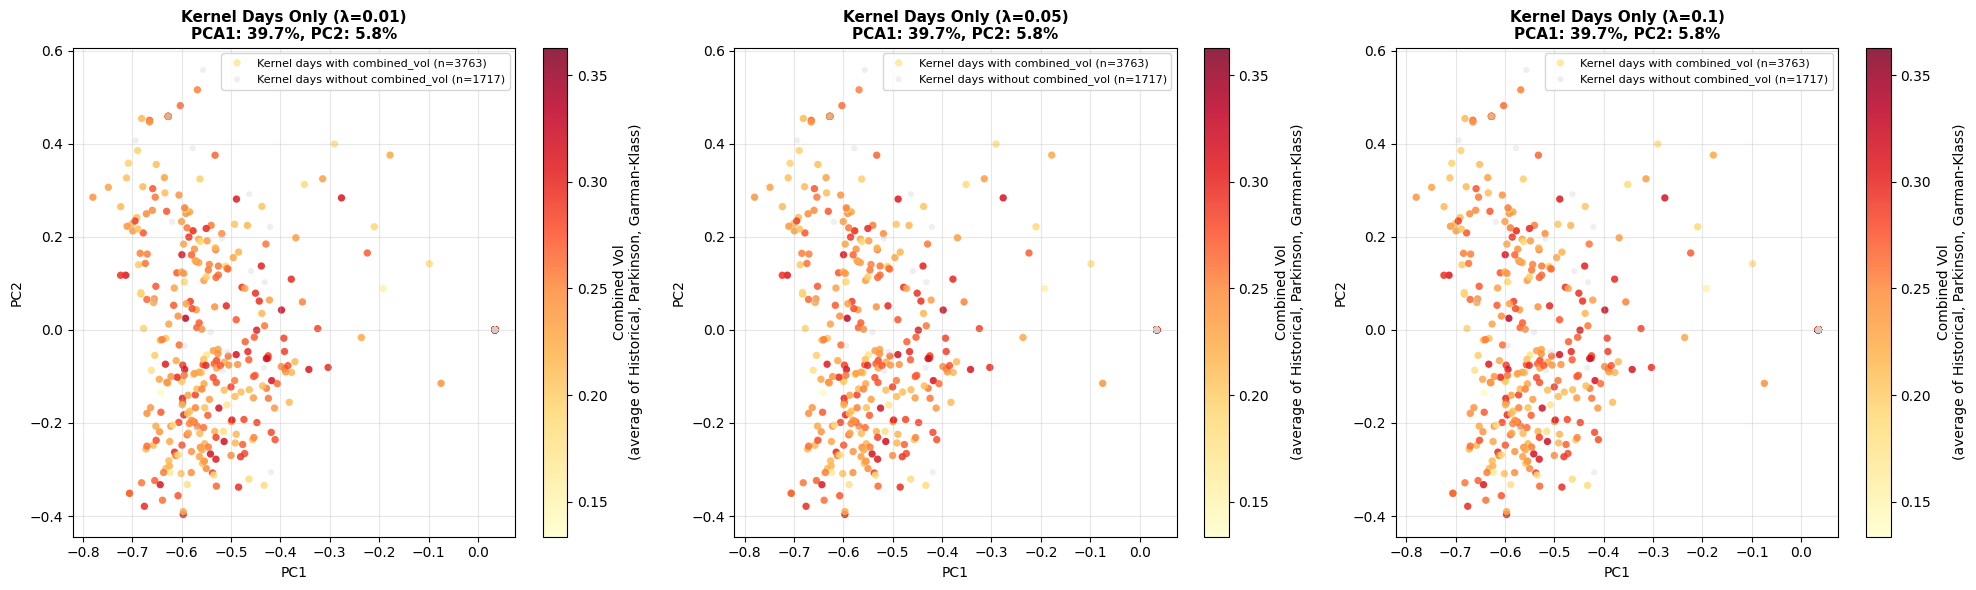

In [25]:
# Apply PCA for visualization (one for each lambda)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Force coloring by average of all volatility estimators
vol_col = 'combined_vol'
if vol_col not in vol_ts_clean.columns:
    raise ValueError("combined_vol not found. Run Cell 13 first to compute combined volatility.")

# Build volatility map from combined volatility only
vol_map_df = vol_ts_clean[['Date_norm', 'combined_vol']].drop_duplicates(subset=['Date_norm']).rename(
    columns={'Date_norm': 'date_norm'}
)

for idx, lam in enumerate(lambdas):
    ax = axes[idx]

    # Full kernel-aggregated context for ALL days in time_steps_range
    z_context_full = z_context_dict[lam]

    # PCA on kernel days only
    if z_context_full.shape[0] > 1 and z_context_full.shape[1] > 1:
        pca = PCA(n_components=2, random_state=42)
        x_2d_context_full = pca.fit_transform(z_context_full)
    else:
        x_2d_context_full = np.zeros((z_context_full.shape[0], 2))
        pca = None

    # Full daily context dataframe (all kernel days)
    kernel_plot_df = pd.DataFrame({
        'date': pd.to_datetime(time_steps_range),
        'x': x_2d_context_full[:, 0],
        'y': x_2d_context_full[:, 1]
    })
    kernel_plot_df['date_norm'] = kernel_plot_df['date'].dt.normalize()
    kernel_plot_df = kernel_plot_df.merge(vol_map_df, on='date_norm', how='left')

    # Color kernel days by combined volatility where available
    kernel_with_vol = kernel_plot_df.dropna(subset=[vol_col]).copy()
    if not kernel_with_vol.empty:
        q_low, q_high = kernel_with_vol[vol_col].quantile([0.05, 0.95])
        kernel_with_vol['vol_clip'] = kernel_with_vol[vol_col].clip(q_low, q_high)

        sc = ax.scatter(
            kernel_with_vol['x'],
            kernel_with_vol['y'],
            c=kernel_with_vol['vol_clip'],
            cmap='YlOrRd',
            alpha=0.85,
            s=28,
            edgecolors='none',
            label=f'Kernel days with combined_vol (n={len(kernel_with_vol)})',
            marker='o'
        )

        # Show remaining kernel days (no volatility available yet)
        kernel_no_vol = kernel_plot_df[kernel_plot_df[vol_col].isna()]
        if not kernel_no_vol.empty:
            ax.scatter(
                kernel_no_vol['x'],
                kernel_no_vol['y'],
                c='lightgray',
                alpha=0.35,
                s=20,
                edgecolors='none',
                label=f'Kernel days without combined_vol (n={len(kernel_no_vol)})',
                marker='o'
            )

        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label('Combined Vol\n(average of Historical, Parkinson, Garman-Klass)')
    else:
        ax.scatter(
            kernel_plot_df['x'],
            kernel_plot_df['y'],
            c='lightgray',
            alpha=0.5,
            s=22,
            edgecolors='none',
            label=f'Kernel days (all, n={len(kernel_plot_df)})',
            marker='o'
        )

    pca_info = f"\nPCA1: {pca.explained_variance_ratio_[0]:.1%}, PC2: {pca.explained_variance_ratio_[1]:.1%}" if pca else ""
    ax.set_title(f'Kernel Days Only (λ={lam}){pca_info}', fontweight='bold', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.savefig('images/kernel_days_combined_vol_colormap.png', dpi=150, bbox_inches='tight')
print("✓ Saved to images/kernel_days_combined_vol_colormap.png")
print(f"  Kernel context days shown (all): {len(time_steps_range)}")
print(f"  Kernel days with combined volatility: {kernel_plot_df['combined_vol'].notna().sum()}")
plt.show()


### Math Behind The Correlation Analysis

For each decay value $\lambda$, we take kernel context vectors over aligned days and reduce them to one principal component:

$$
\mathbf{z}_t^{(\lambda)} \in \mathbb{R}^D \;\xrightarrow{\text{PCA}}\; \text{PC1}_t
$$

So each day $t$ has:

- a scalar context score: $x_t = \text{PC1}_t$
- a volatility value: $y_t = \text{vol}_{20d,t}$

The reported number is the Pearson correlation:

$$
r_{x,y} = \frac{\sum_{t \in \mathcal{T}} (x_t-\bar{x})(y_t-\bar{y})}{\sqrt{\sum_{t \in \mathcal{T}} (x_t-\bar{x})^2}\sqrt{\sum_{t \in \mathcal{T}} (y_t-\bar{y})^2}}
$$

where $\mathcal{T}$ is the set of valid days (non-NaN volatility).

Interpretation:

- $r \approx +1$: higher kernel-context PC1 aligns with higher volatility.
- $r \approx -1$: higher PC1 aligns with lower volatility.
- $r \approx 0$: little linear relationship.

The cell also prints PCA explained variance:

$$
\text{ExplainedVariance(PC1)} = \frac{\lambda_1}{\sum_{j=1}^{D} \lambda_j}
$$

where $\lambda_1$ is the largest eigenvalue of the covariance matrix of kernel embeddings for that $\lambda$.

In [26]:
# Analyze correlation between kernel context and volatility
print("=== Kernel Aggregation Analysis ===\n")

for lam in lambdas:
    z_context = z_context_dict[lam]
    
    # Use only rows from merged_df
    z_context_subset = np.array([z_context[i] if i < len(z_context) else np.zeros(z_context.shape[1]) 
                                  for i in range(len(merged_df))])
    
    if z_context_subset.shape[0] > 1 and z_context_subset.shape[1] > 1:
        pca = PCA(n_components=1, random_state=42)
        pc1 = pca.fit_transform(z_context_subset).flatten()
        
        # Correlation with volatility
        valid_idx = ~np.isnan(merged_df['vol_20d'].values)
        if valid_idx.sum() > 1:
            corr = np.corrcoef(pc1[valid_idx], merged_df['vol_20d'].values[valid_idx])[0, 1]
            print(f"λ={lam}: PC1-Volatility correlation = {corr:.4f}")
        
        # Variance explained
        print(f"  Explained variance (PC1): {pca.explained_variance_ratio_[0]:.2%}")
        print()

# Summary statistics
print("Event Statistics:")
print(f"  Total news articles: {len(cluster_df)}")
print(f"  Date span: {cluster_df['date'].min().date()} to {cluster_df['date'].max().date()}")
print(f"  Days covered: {(cluster_df['date'].max() - cluster_df['date'].min()).days}")
print(f"  Avg articles per week: {len(cluster_df) / ((cluster_df['date'].max() - cluster_df['date'].min()).days / 7):.1f}")
print(f"  Embedding dimension: {x_text.shape[1]}")
print(f"\nVolatility Statistics:")
print(merged_df['vol_20d'].describe())

=== Kernel Aggregation Analysis ===

λ=0.01: PC1-Volatility correlation = 0.0060
  Explained variance (PC1): 40.76%

λ=0.05: PC1-Volatility correlation = 0.0060
  Explained variance (PC1): 40.76%

λ=0.1: PC1-Volatility correlation = 0.0060
  Explained variance (PC1): 40.76%

Event Statistics:
  Total news articles: 642
  Date span: 2010-04-15 to 2025-04-15
  Days covered: 5479
  Avg articles per week: 0.8
  Embedding dimension: 384

Volatility Statistics:
count    3763.000000
mean        0.263238
std         0.116479
min         0.082242
25%         0.189664
50%         0.241029
75%         0.303240
max         0.950589
Name: vol_20d, dtype: float64
